# ecgGAN Pipeline — Generate Sintetis AMI (PyTorch)

**Arsitektur:** BiLSTM-CNN GAN (Zhu et al., 2019 / MikhailMurashov/ecgGAN)  
**Framework:** PyTorch (reimplementasi dari Keras/TensorFlow)  
**Training:** WGAN-GP

### Pipeline:
1. **Step 1:** Load sinyal AMI dari PTB-XL (.dat/.hea)
2. **Step 2:** Train BiLSTM-CNN GAN pada sinyal 10 detik  
3. **Step 3:** Generate 100 sinyal sintetis 10 detik
4. **Step 4:** Plot EKG full → potong 10 segmen → resize PNG

**Hasil:** 100 EKG × 10 segmen = **1000 PNG segmen sintetis class AMI**

> ⚠️ Data sintetis **HANYA untuk TRAINING** ViT. Data asli tetap untuk **TESTING**.

## 0. Install & Imports

In [3]:
# Install wfdb (untuk baca PTB-XL)
!pip install -q wfdb


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [4]:
import os, sys, random, json, warnings, glob
import numpy as np
from datetime import datetime
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import wfdb
import pandas as pd
import ast

warnings.filterwarnings('ignore')

# Seed
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Device: cuda
   GPU: NVIDIA GeForce RTX 3090


## 1. Konfigurasi

In [8]:
# ============================================================
# SESUAIKAN BAGIAN INI DENGAN SETUP KAMU
# ============================================================

# Path ke folder PTB-XL dataset
PTBXL_PATH = "/workspace/data/ptb-xl"      # ← UBAH SESUAI LOKASI KAMU

# Output
OUTPUT_DIR = "/workspace/ecg_gan_ami2"
CLASS_NAME = "AMI"

# Jumlah EKG full yang di-generate (×10 segmen = total PNG)
N_GENERATE = 100   # 100 × 10 = 1000 segmen

# ============================================================
# PARAMETER GAN (bisa diubah, tapi default sudah bagus)
# ============================================================
N_LEADS = 12
LEAD_NAMES = ['I', 'II', 'III', 'AVR', 'AVL', 'AVF',
              'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

LATENT_DIM = 100            # Dimensi noise vector
BILSTM_UNITS = 128          # BiLSTM hidden units (paper: 128)
BILSTM_LAYERS = 2           # BiLSTM layers (paper: 2)
DROPOUT = 0.3               # Dropout (paper: ada dropout)

BATCH_SIZE = 32
EPOCHS = 500                # Naikkan ke 800-1000 jika data sedikit
LR_GEN = 0.0002
LR_DISC = 0.0001
BETA1 = 0.5
BETA2 = 0.999
N_CRITIC = 2                # Disc updates per gen update
GP_LAMBDA = 10.0            # WGAN-GP gradient penalty
SAVE_INTERVAL = 50

# PNG segmen (sesuai ukuran segmen asli kamu)
SEG_WIDTH = 390             # Pixel
SEG_HEIGHT = 989            # Pixel
PNG_DPI = 100
LINE_WIDTH = 0.8
N_SEGMENTS = 10             # Potong EKG 10s jadi 10 segmen

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Konfigurasi:")
print(f"   PTB-XL path   : {PTBXL_PATH}")
print(f"   Output         : {OUTPUT_DIR}")
print(f"   Class          : {CLASS_NAME}")
print(f"   Generate       : {N_GENERATE} EKG × {N_SEGMENTS} segmen = {N_GENERATE * N_SEGMENTS} PNG")
print(f"   Epochs         : {EPOCHS}")
print(f"   BiLSTM         : {BILSTM_LAYERS} layers × {BILSTM_UNITS} units")

✅ Konfigurasi:
   PTB-XL path   : /workspace/data/ptb-xl
   Output         : /workspace/ecg_gan_ami2
   Class          : AMI
   Generate       : 100 EKG × 10 segmen = 1000 PNG
   Epochs         : 500
   BiLSTM         : 2 layers × 128 units


## 2. Step 1 — Load Sinyal AMI dari PTB-XL

Membaca sinyal EKG 12-lead dari file WFDB (.dat/.hea), filter hanya class AMI.

In [9]:
# === STEP 1: Load sinyal AMI dari PTB-XL ===

print("=" * 65)
print("  STEP 1: LOAD SINYAL AMI DARI PTB-XL")
print("=" * 65)

# Load metadata
csv_path = os.path.join(PTBXL_PATH, "ptbxl_database.csv")
assert os.path.exists(csv_path), f"❌ File tidak ditemukan: {csv_path}"

df = pd.read_csv(csv_path, index_col='ecg_id')
print(f"  📊 Total records: {len(df)}")

# Parse scp_codes
df['scp_codes_parsed'] = df['scp_codes'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Filter AMI
ami_records = df[df['scp_codes_parsed'].apply(
    lambda codes: 'AMI' in codes if isinstance(codes, dict) else False
)]
print(f"  📊 AMI records: {len(ami_records)}")

# Jika tidak ditemukan, coba pattern matching
if len(ami_records) == 0:
    print("  ⚠ Coba pattern matching...")
    ami_records = df[df['scp_codes_parsed'].apply(
        lambda codes: any('ami' in k.lower() or 'AMI' in k
                        for k in (codes.keys() if isinstance(codes, dict) else []))
    )]
    print(f"  📊 AMI records (pattern): {len(ami_records)}")

if len(ami_records) == 0:
    all_codes = set()
    for codes in df['scp_codes_parsed']:
        if isinstance(codes, dict):
            all_codes.update(codes.keys())
    mi_related = [c for c in sorted(all_codes) if 'mi' in c.lower() or 'infarc' in c.lower()]
    print(f"  ❌ Tidak ada AMI! MI-related codes yang tersedia: {mi_related}")

# Detect sampling rate
if os.path.exists(os.path.join(PTBXL_PATH, "records500")):
    SAMPLING_RATE = 500
    FILENAME_COL = 'filename_hr'
else:
    SAMPLING_RATE = 100
    FILENAME_COL = 'filename_lr'

SEQ_LEN = SAMPLING_RATE * 10  # 10 detik
print(f"  📊 Sampling rate: {SAMPLING_RATE} Hz")
print(f"  📊 Seq length: {SEQ_LEN} samples")

  STEP 1: LOAD SINYAL AMI DARI PTB-XL
  📊 Total records: 21799
  📊 AMI records: 353
  📊 Sampling rate: 100 Hz
  📊 Seq length: 1000 samples


In [10]:
# === Load sinyal ===
print(f"  🔄 Loading {len(ami_records)} sinyal AMI...")

signals_list = []
failed = 0

for idx, row in ami_records.iterrows():
    try:
        record_path = os.path.join(PTBXL_PATH, row[FILENAME_COL])
        record = wfdb.rdrecord(record_path)
        sig = record.p_signal.T  # (n_leads, seq_len)

        if sig.shape[0] >= 12:
            sig = sig[:12, :]
        else:
            sig = np.vstack([sig, np.zeros((12 - sig.shape[0], sig.shape[1]))])

        if sig.shape[1] >= SEQ_LEN:
            sig = sig[:, :SEQ_LEN]
        else:
            sig = np.hstack([sig, np.zeros((12, SEQ_LEN - sig.shape[1]))])

        signals_list.append(sig)
    except Exception as e:
        failed += 1

data_raw = np.array(signals_list, dtype=np.float32)
data_raw = np.nan_to_num(data_raw, nan=0.0)

print(f"  ✅ Loaded: {data_raw.shape}  ({failed} failed)")

  🔄 Loading 353 sinyal AMI...
  ✅ Loaded: (353, 12, 1000)  (0 failed)


  ✅ Normalized to [-1, 1]
  📊 Shape: (353, 12, 1000)


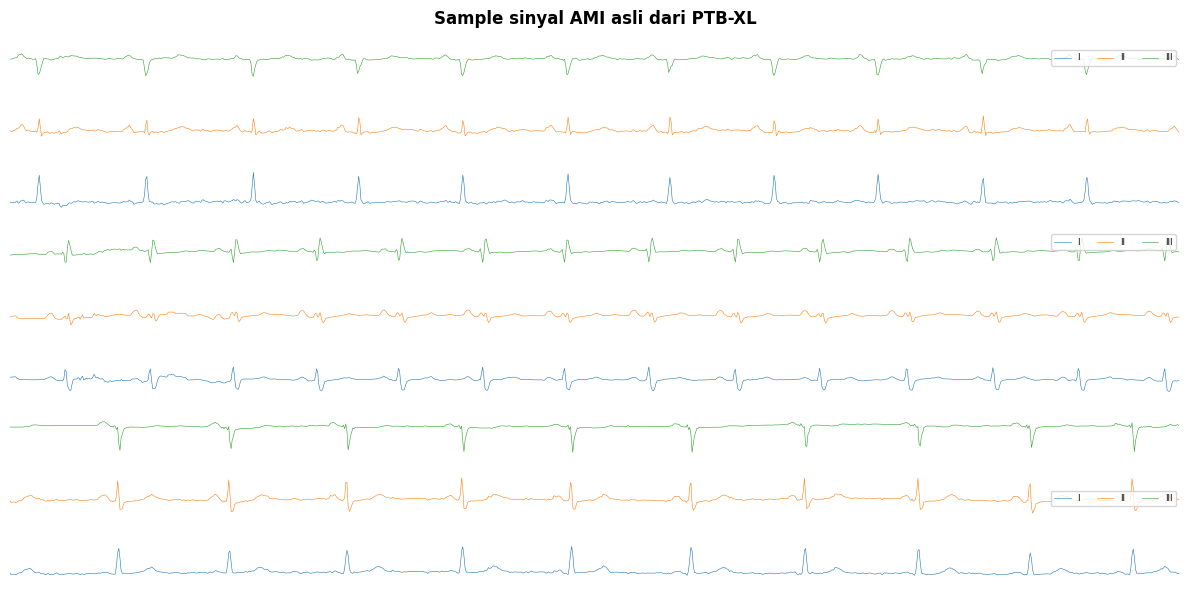

✅ Step 1 selesai!


In [11]:
# === Normalisasi ke [-1, 1] ===
scaler = {}
data_norm = data_raw.copy()

for lead in range(data_norm.shape[1]):
    vmin = float(data_norm[:, lead, :].min())
    vmax = float(data_norm[:, lead, :].max())
    scaler[lead] = {'min': vmin, 'max': vmax}
    rng = vmax - vmin
    if rng > 1e-8:
        data_norm[:, lead, :] = 2.0 * (data_norm[:, lead, :] - vmin) / rng - 1.0
    else:
        data_norm[:, lead, :] = 0.0

# Save scaler
with open(f"{OUTPUT_DIR}/scaler.json", 'w') as f:
    json.dump({str(k): v for k, v in scaler.items()}, f, indent=2)

print(f"  ✅ Normalized to [-1, 1]")
print(f"  📊 Shape: {data_norm.shape}")

# Visualisasi sample
fig, axes = plt.subplots(3, 1, figsize=(12, 6))
for i in range(3):
    idx = random.randint(0, data_raw.shape[0] - 1)
    for lead in range(3):
        axes[i].plot(data_raw[idx, lead, :] + lead * 2, lw=0.4,
                    label=LEAD_NAMES[lead])
    axes[i].legend(fontsize=6, ncol=3)
    axes[i].set_xlim(0, SEQ_LEN)
    axes[i].axis('off')
plt.suptitle('Sample sinyal AMI asli dari PTB-XL', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/sample_real_ami.png", dpi=100)
plt.show()
print("✅ Step 1 selesai!")

## 3. Step 2 — Arsitektur & Training BiLSTM-CNN GAN

Arsitektur identik dengan ecgGAN (Murashov / Zhu et al. 2019):
- **Generator:** Noise → BiLSTM (2×128) → Dropout → Conv1d (LeakyReLU) → Conv1d (Tanh)
- **Discriminator:** Conv1d + LeakyReLU (4 pairs) → Dense(1)
- **Training:** WGAN-GP

In [12]:
# === ARSITEKTUR GENERATOR (BiLSTM + Conv1d) ===

class BiLSTMGenerator(nn.Module):
    def __init__(self, latent_dim, n_leads, seq_len):
        super().__init__()
        self.seq_len = seq_len
        self.init_len = seq_len // 8

        self.fc_in = nn.Sequential(
            nn.Linear(latent_dim, self.init_len * 64),
            nn.LeakyReLU(0.2)
        )

        # BiLSTM: 2 layers, 128 units (paper)
        self.bilstm = nn.LSTM(
            input_size=64,
            hidden_size=BILSTM_UNITS,
            num_layers=BILSTM_LAYERS,
            batch_first=True,
            bidirectional=True,
            dropout=DROPOUT
        )

        self.drop = nn.Dropout(DROPOUT)
        bilstm_out = BILSTM_UNITS * 2  # 256

        # Conv1d: LeakyReLU hidden, Tanh output (paper)
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
            nn.Conv1d(bilstm_out, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
            nn.Conv1d(128, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv1d(32, n_leads, kernel_size=7, padding=3),
            nn.Tanh()
        )

        for m in self.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                nn.init.normal_(m.weight, 0.0, 0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, z):
        batch = z.size(0)
        x = self.fc_in(z)
        x = x.view(batch, self.init_len, 64)
        x, _ = self.bilstm(x)
        x = self.drop(x)
        x = x.permute(0, 2, 1)
        x = self.upsample(x)
        if x.size(2) >= self.seq_len:
            x = x[:, :, :self.seq_len]
        else:
            x = nn.functional.pad(x, (0, self.seq_len - x.size(2)))
        return x


# === ARSITEKTUR DISCRIMINATOR (CNN) ===

class CNNDiscriminator(nn.Module):
    def __init__(self, n_leads, seq_len):
        super().__init__()

        # Conv-Pool pairs (paper: LeakyReLU on hidden)
        self.features = nn.Sequential(
            nn.Conv1d(n_leads, 64, kernel_size=5, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AvgPool1d(4, 4),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AvgPool1d(4, 4),

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AvgPool1d(4, 4),

            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AvgPool1d(4, 4),
        )

        with torch.no_grad():
            flat_size = self.features(torch.zeros(1, n_leads, seq_len)).view(1, -1).size(1)

        # Dense → 1 (paper)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

        for m in self.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                nn.init.normal_(m.weight, 0.0, 0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.classifier(self.features(x))


# === GRADIENT PENALTY (WGAN-GP) ===

def gradient_penalty(disc, real, fake):
    bs = real.size(0)
    alpha = torch.rand(bs, 1, 1, device=device)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_out = disc(interp)
    grads = torch.autograd.grad(
        outputs=d_out, inputs=interp,
        grad_outputs=torch.ones_like(d_out),
        create_graph=True, retain_graph=True
    )[0]
    return ((grads.view(bs, -1).norm(2, dim=1) - 1) ** 2).mean()


# Init models
gen = BiLSTMGenerator(LATENT_DIM, N_LEADS, SEQ_LEN).to(device)
disc = CNNDiscriminator(N_LEADS, SEQ_LEN).to(device)

g_params = sum(p.numel() for p in gen.parameters())
d_params = sum(p.numel() for p in disc.parameters())

print(f"✅ Models created:")
print(f"   Generator params:     {g_params:,}")
print(f"   Discriminator params: {d_params:,}")

✅ Models created:
   Generator params:     1,702,252
   Discriminator params: 438,977


In [13]:
# === TRAINING LOOP ===

tensor_data = torch.FloatTensor(data_norm).to(device)
loader = DataLoader(TensorDataset(tensor_data),
                    batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

opt_g = optim.Adam(gen.parameters(), lr=LR_GEN, betas=(BETA1, BETA2))
opt_d = optim.Adam(disc.parameters(), lr=LR_DISC, betas=(BETA1, BETA2))
sch_g = optim.lr_scheduler.CosineAnnealingLR(opt_g, T_max=EPOCHS, eta_min=1e-6)
sch_d = optim.lr_scheduler.CosineAnnealingLR(opt_d, T_max=EPOCHS, eta_min=1e-6)

fixed_z = torch.randn(4, LATENT_DIM, device=device)
os.makedirs(f"{OUTPUT_DIR}/progress", exist_ok=True)

history = {'d_loss': [], 'g_loss': [], 'w_dist': [], 'gp': []}

print("=" * 65)
print("  STEP 2: TRAINING ecgGAN")
print("=" * 65)
print(f"  {EPOCHS} epochs, {len(loader)} batches/epoch")
print()

start = datetime.now()

for epoch in range(1, EPOCHS + 1):
    ep_d, ep_g, ep_w, ep_gp, nb = 0, 0, 0, 0, 0

    for (real,) in loader:
        bs = real.size(0)

        # Train Discriminator
        for _ in range(N_CRITIC):
            disc.zero_grad()
            d_real = disc(real).mean()
            z = torch.randn(bs, LATENT_DIM, device=device)
            fake = gen(z).detach()
            d_fake = disc(fake).mean()
            gp = gradient_penalty(disc, real, fake)
            w = d_real - d_fake
            d_loss = -w + GP_LAMBDA * gp
            d_loss.backward()
            opt_d.step()

        # Train Generator
        gen.zero_grad()
        z = torch.randn(bs, LATENT_DIM, device=device)
        g_loss = -disc(gen(z)).mean()
        g_loss.backward()
        opt_g.step()

        ep_d += d_loss.item(); ep_g += g_loss.item()
        ep_w += w.item(); ep_gp += gp.item()
        nb += 1

    sch_g.step(); sch_d.step()

    for k, v in [('d_loss', ep_d), ('g_loss', ep_g),
                  ('w_dist', ep_w), ('gp', ep_gp)]:
        history[k].append(v / max(nb, 1))

    if epoch % 10 == 0 or epoch == 1:
        el = datetime.now() - start
        print(f"  Epoch [{epoch:4d}/{EPOCHS}]  "
              f"D:{history['d_loss'][-1]:+.4f}  "
              f"G:{history['g_loss'][-1]:+.4f}  "
              f"W:{history['w_dist'][-1]:.4f}  "
              f"GP:{history['gp'][-1]:.4f}  [{el}]")

    if epoch % SAVE_INTERVAL == 0 or epoch == 1:
        gen.eval()
        with torch.no_grad():
            samp = gen(fixed_z).cpu().numpy()
        gen.train()
        fig, ax = plt.subplots(1, 1, figsize=(10, 2))
        for lead in range(3):
            ax.plot(samp[0, lead, :] + lead * 2, lw=0.3)
        ax.set_xlim(0, samp.shape[2]); ax.axis('off')
        plt.title(f'Epoch {epoch}')
        plt.savefig(f"{OUTPUT_DIR}/progress/epoch_{epoch:04d}.png", dpi=80)
        plt.close()

total_time = datetime.now() - start
print(f"\n  ✅ Training selesai! Waktu: {total_time}")

# Save model
torch.save({
    'generator': gen.state_dict(),
    'discriminator': disc.state_dict(),
    'config': {
        'latent_dim': LATENT_DIM, 'n_leads': N_LEADS,
        'seq_len': SEQ_LEN, 'sampling_rate': SAMPLING_RATE,
        'bilstm_units': BILSTM_UNITS, 'bilstm_layers': BILSTM_LAYERS,
        'dropout': DROPOUT,
    },
    'history': history,
}, f"{OUTPUT_DIR}/ecg_gan_model.pth")
print(f"  💾 Model: {OUTPUT_DIR}/ecg_gan_model.pth")

  STEP 2: TRAINING ecgGAN
  500 epochs, 11 batches/epoch

  Epoch [   1/500]  D:+9.9595  G:-0.0138  W:0.0121  GP:0.9972  [0:00:01.154752]
  Epoch [  10/500]  D:+2.1208  G:+3.5253  W:0.2193  GP:0.2340  [0:00:06.260016]
  Epoch [  20/500]  D:+0.0963  G:-10.6879  W:0.0855  GP:0.0182  [0:00:11.948743]
  Epoch [  30/500]  D:+5.1416  G:-0.2900  W:-0.1855  GP:0.4956  [0:00:17.485211]
  Epoch [  40/500]  D:+0.0742  G:-4.6939  W:0.0533  GP:0.0127  [0:00:23.022657]
  Epoch [  50/500]  D:+1.0104  G:-21.8823  W:-0.8598  GP:0.0151  [0:00:28.554172]
  Epoch [  60/500]  D:-1.4486  G:-14.9451  W:1.6519  GP:0.0203  [0:00:34.270147]
  Epoch [  70/500]  D:-0.8859  G:-15.6437  W:0.9847  GP:0.0099  [0:00:39.893056]
  Epoch [  80/500]  D:-1.2301  G:-8.8695  W:1.3680  GP:0.0138  [0:00:45.551126]
  Epoch [  90/500]  D:-0.7463  G:-26.1011  W:0.8104  GP:0.0064  [0:00:51.210651]
  Epoch [ 100/500]  D:-0.2458  G:-27.1425  W:0.3210  GP:0.0075  [0:00:56.848402]
  Epoch [ 110/500]  D:-0.2131  G:-19.8312  W:0.3274  G

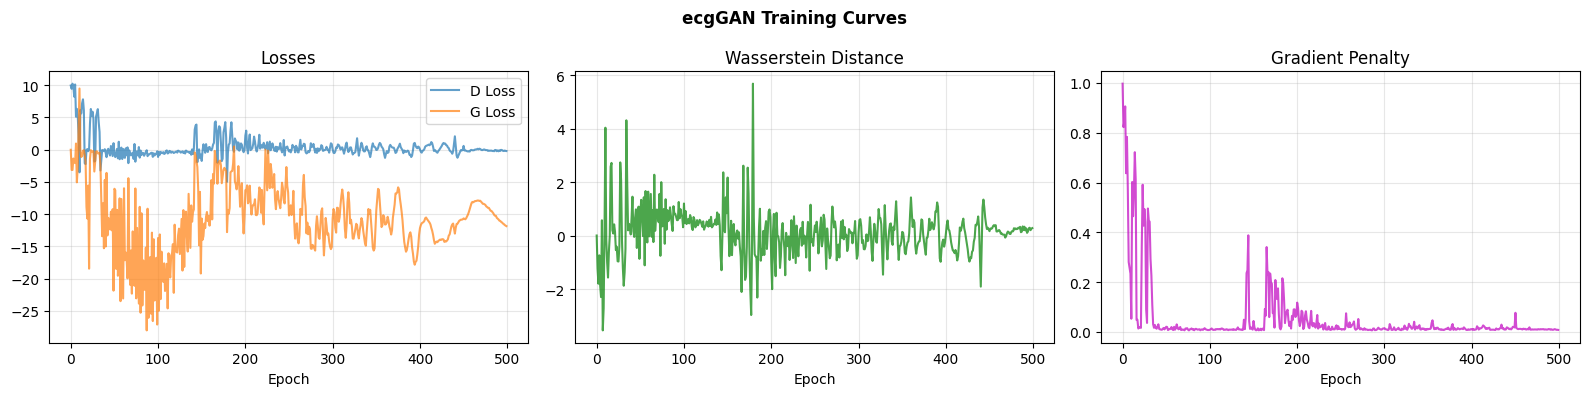

✅ Epochs: 500


In [15]:
import torch
import matplotlib.pyplot as plt

ckpt = torch.load(f"{OUTPUT_DIR}/ecg_gan_model.pth", map_location='cpu')
history = ckpt['history']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history['d_loss'], alpha=0.7, label='D Loss')
axes[0].plot(history['g_loss'], alpha=0.7, label='G Loss')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_title('Losses')
axes[0].set_xlabel('Epoch')
axes[1].plot(history['w_dist'], 'g-', alpha=0.7)
axes[1].set_title('Wasserstein Distance'); axes[1].grid(alpha=0.3)
axes[1].set_xlabel('Epoch')
axes[2].plot(history['gp'], 'm-', alpha=0.7)
axes[2].set_title('Gradient Penalty'); axes[2].grid(alpha=0.3)
axes[2].set_xlabel('Epoch')
plt.suptitle('ecgGAN Training Curves', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
plt.show()

print(f"✅ Epochs: {len(history['d_loss'])}")

In [6]:
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

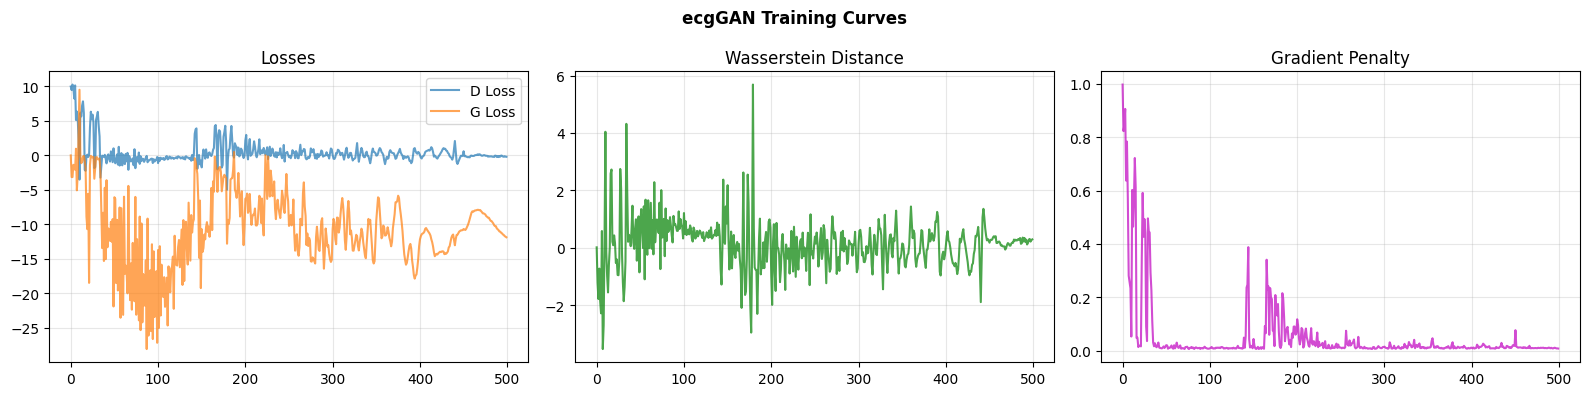

In [16]:
# === Training Curves ===
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history['d_loss'], alpha=0.7, label='D Loss')
axes[0].plot(history['g_loss'], alpha=0.7, label='G Loss')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_title('Losses')
axes[1].plot(history['w_dist'], 'g-', alpha=0.7)
axes[1].set_title('Wasserstein Distance'); axes[1].grid(alpha=0.3)
axes[2].plot(history['gp'], 'm-', alpha=0.7)
axes[2].set_title('Gradient Penalty'); axes[2].grid(alpha=0.3)
plt.suptitle('ecgGAN Training Curves', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
plt.show()

## 4. Step 3 — Generate Sinyal Sintetis

Generate 100 sinyal EKG AMI sintetis (10 detik, 12 lead), lalu denormalisasi ke skala asli.

In [17]:
# === STEP 3: Generate sinyal sintetis ===

def denormalize(data, scaler):
    result = data.copy()
    for lead in range(min(data.shape[1], len(scaler))):
        s = scaler[lead]
        result[:, lead, :] = (data[:, lead, :] + 1) / 2 * (s['max'] - s['min']) + s['min']
    return result

gen.eval()
print(f"  🔄 Generating {N_GENERATE} sinyal sintetis (10 detik)...")

all_sigs = []
with torch.no_grad():
    remaining = N_GENERATE
    while remaining > 0:
        bs = min(64, remaining)
        z = torch.randn(bs, LATENT_DIM, device=device)
        fake = gen(z).cpu().numpy()
        all_sigs.append(fake)
        remaining -= bs

synthetic_signals = np.concatenate(all_sigs, axis=0)[:N_GENERATE]
synthetic_signals = denormalize(synthetic_signals, scaler)

np.save(f"{OUTPUT_DIR}/synthetic_signals.npy", synthetic_signals)
print(f"  ✅ Generated: {synthetic_signals.shape}")
print(f"  💾 Saved: {OUTPUT_DIR}/synthetic_signals.npy")

  🔄 Generating 100 sinyal sintetis (10 detik)...
  ✅ Generated: (100, 12, 1000)
  💾 Saved: /workspace/ecg_gan_ami2/synthetic_signals.npy


  📊 Statistik per lead:
     Lead     Real μ    Syn μ   Real σ    Syn σ
     --------------------------------------
     I        -0.002   -0.034    0.158    0.505
     II       -0.002   -0.085    0.153    0.326
     III       0.000   -0.045    0.166    0.399
     AVR       0.002    0.032    0.132    0.244
     AVL      -0.001    0.002    0.143    0.488
     AVF      -0.001   -0.099    0.138    0.377
     V1        0.002   -0.188    0.210    0.424
     V2       -0.001    0.057    0.293    0.465
     V3       -0.003   -0.167    0.302    0.866
     V4       -0.002   -0.225    0.311    0.554
     V5       -0.002    0.189    0.281    0.514
     V6       -0.002   -0.284    0.241    0.808


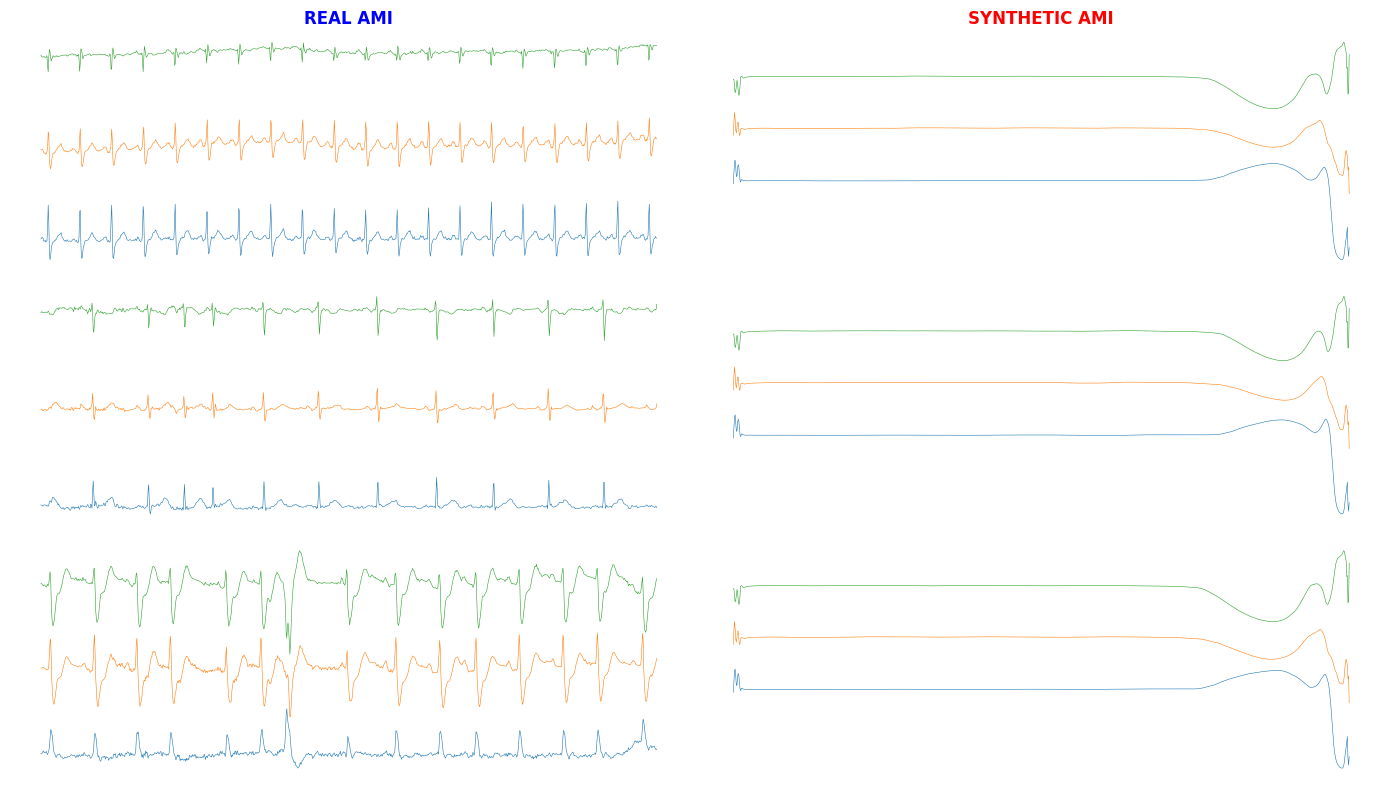

In [18]:
# === Evaluasi: Real vs Synthetic ===
print(f"  📊 Statistik per lead:")
print(f"     {'Lead':<6} {'Real μ':>8} {'Syn μ':>8} {'Real σ':>8} {'Syn σ':>8}")
print(f"     {'-'*38}")
for i, name in enumerate(LEAD_NAMES):
    print(f"     {name:<6} {data_raw[:,i].mean():>8.3f} {synthetic_signals[:,i].mean():>8.3f} "
          f"{data_raw[:,i].std():>8.3f} {synthetic_signals[:,i].std():>8.3f}")

# Visual comparison
fig, axes = plt.subplots(3, 2, figsize=(14, 8))
for i in range(3):
    ri = random.randint(0, data_raw.shape[0]-1)
    si = random.randint(0, synthetic_signals.shape[0]-1)
    for lead in range(3):
        axes[i,0].plot(data_raw[ri, lead] + lead*2, lw=0.4)
        axes[i,1].plot(synthetic_signals[si, lead] + lead*2, lw=0.4)
    axes[i,0].axis('off'); axes[i,1].axis('off')
    if i == 0:
        axes[i,0].set_title('REAL AMI', color='blue', fontweight='bold')
        axes[i,1].set_title('SYNTHETIC AMI', color='red', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/signal_comparison.png", dpi=150)
plt.show()

## 5. Step 4 — Segmentasi + Render ke PNG

Tiap sinyal 10 detik dipotong jadi 10 segmen (~1 detik), lalu dirender ke PNG dengan format identik segmen asli (390×989 px, 12 lead, label di kiri).

In [19]:
# === Render function ===

def render_segment_png(signal_12lead, save_path):
    """Render 1 segmen ke PNG (format identik segmen asli)."""
    n_leads = signal_12lead.shape[0]
    fig_w = SEG_WIDTH / PNG_DPI
    fig_h = SEG_HEIGHT / PNG_DPI

    fig = plt.figure(figsize=(fig_w, fig_h), dpi=PNG_DPI, facecolor='white')
    gs = gridspec.GridSpec(n_leads, 1, hspace=0.05,
                           left=0.15, right=0.98, top=0.98, bottom=0.02)

    for i in range(n_leads):
        ax = fig.add_subplot(gs[i, 0])
        sig = signal_12lead[i, :]
        smin, smax = sig.min(), sig.max()
        if smax - smin > 1e-8:
            sig_norm = (sig - smin) / (smax - smin)
        else:
            sig_norm = np.zeros_like(sig) + 0.5

        x = np.linspace(0, 1, len(sig_norm))
        ax.plot(x, sig_norm, color='black', linewidth=LINE_WIDTH, antialiased=True)
        ax.text(-0.10, 0.5, LEAD_NAMES[i], transform=ax.transAxes,
                fontsize=10, fontweight='bold', va='center', ha='right',
                family='sans-serif')
        ax.set_xlim(0, 1)
        ax.set_ylim(-0.1, 1.1)
        ax.axis('off')

    os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
    fig.savefig(save_path, dpi=PNG_DPI, facecolor='white',
                bbox_inches=None, pad_inches=0)
    plt.close(fig)

print("✅ Render function ready")

✅ Render function ready


In [20]:
# === Segmentasi + Render semua ===

seg_samples = SEQ_LEN // N_SEGMENTS
out_dir = os.path.join(OUTPUT_DIR, "synthetic_png", CLASS_NAME)
os.makedirs(out_dir, exist_ok=True)

print("=" * 65)
print("  STEP 4: SEGMENTASI + RENDER → PNG")
print("=" * 65)
print(f"  Sinyal       : {N_GENERATE} × 10 detik")
print(f"  Segmen/EKG   : {N_SEGMENTS}")
print(f"  Samples/seg  : {seg_samples}")
print(f"  Total PNG    : {N_GENERATE * N_SEGMENTS}")
print(f"  Ukuran       : {SEG_WIDTH}×{SEG_HEIGHT} px")
print(f"  Output       : {out_dir}")
print()

total_rendered = 0

for sig_idx in range(N_GENERATE):
    ecg_id = sig_idx + 1
    ecg_folder = os.path.join(out_dir, f"synthetic_{ecg_id:05d}")
    os.makedirs(ecg_folder, exist_ok=True)

    for seg_idx in range(N_SEGMENTS):
        start = seg_idx * seg_samples
        end = start + seg_samples
        segment = synthetic_signals[sig_idx, :, start:end]

        png_path = os.path.join(ecg_folder, f"syn_{ecg_id:05d}_seg{seg_idx:02d}.png")
        render_segment_png(segment, png_path)

        # Resize jika perlu
        try:
            img = Image.open(png_path)
            if img.size != (SEG_WIDTH, SEG_HEIGHT):
                img = img.resize((SEG_WIDTH, SEG_HEIGHT), Image.BICUBIC)
                img.save(png_path)
        except:
            pass

        total_rendered += 1

    if ecg_id % 10 == 0 or ecg_id == 1:
        print(f"     EKG [{ecg_id:4d}/{N_GENERATE}] → {N_SEGMENTS} segmen  (total: {total_rendered})")

print(f"\n  ✅ {total_rendered} PNG segmen disimpan!")

  STEP 4: SEGMENTASI + RENDER → PNG
  Sinyal       : 100 × 10 detik
  Segmen/EKG   : 10
  Samples/seg  : 100
  Total PNG    : 1000
  Ukuran       : 390×989 px
  Output       : /workspace/ecg_gan_ami2/synthetic_png/AMI

     EKG [   1/100] → 10 segmen  (total: 10)
     EKG [  10/100] → 10 segmen  (total: 100)
     EKG [  20/100] → 10 segmen  (total: 200)
     EKG [  30/100] → 10 segmen  (total: 300)
     EKG [  40/100] → 10 segmen  (total: 400)
     EKG [  50/100] → 10 segmen  (total: 500)
     EKG [  60/100] → 10 segmen  (total: 600)
     EKG [  70/100] → 10 segmen  (total: 700)
     EKG [  80/100] → 10 segmen  (total: 800)
     EKG [  90/100] → 10 segmen  (total: 900)
     EKG [ 100/100] → 10 segmen  (total: 1000)

  ✅ 1000 PNG segmen disimpan!


## 6. Preview Hasil

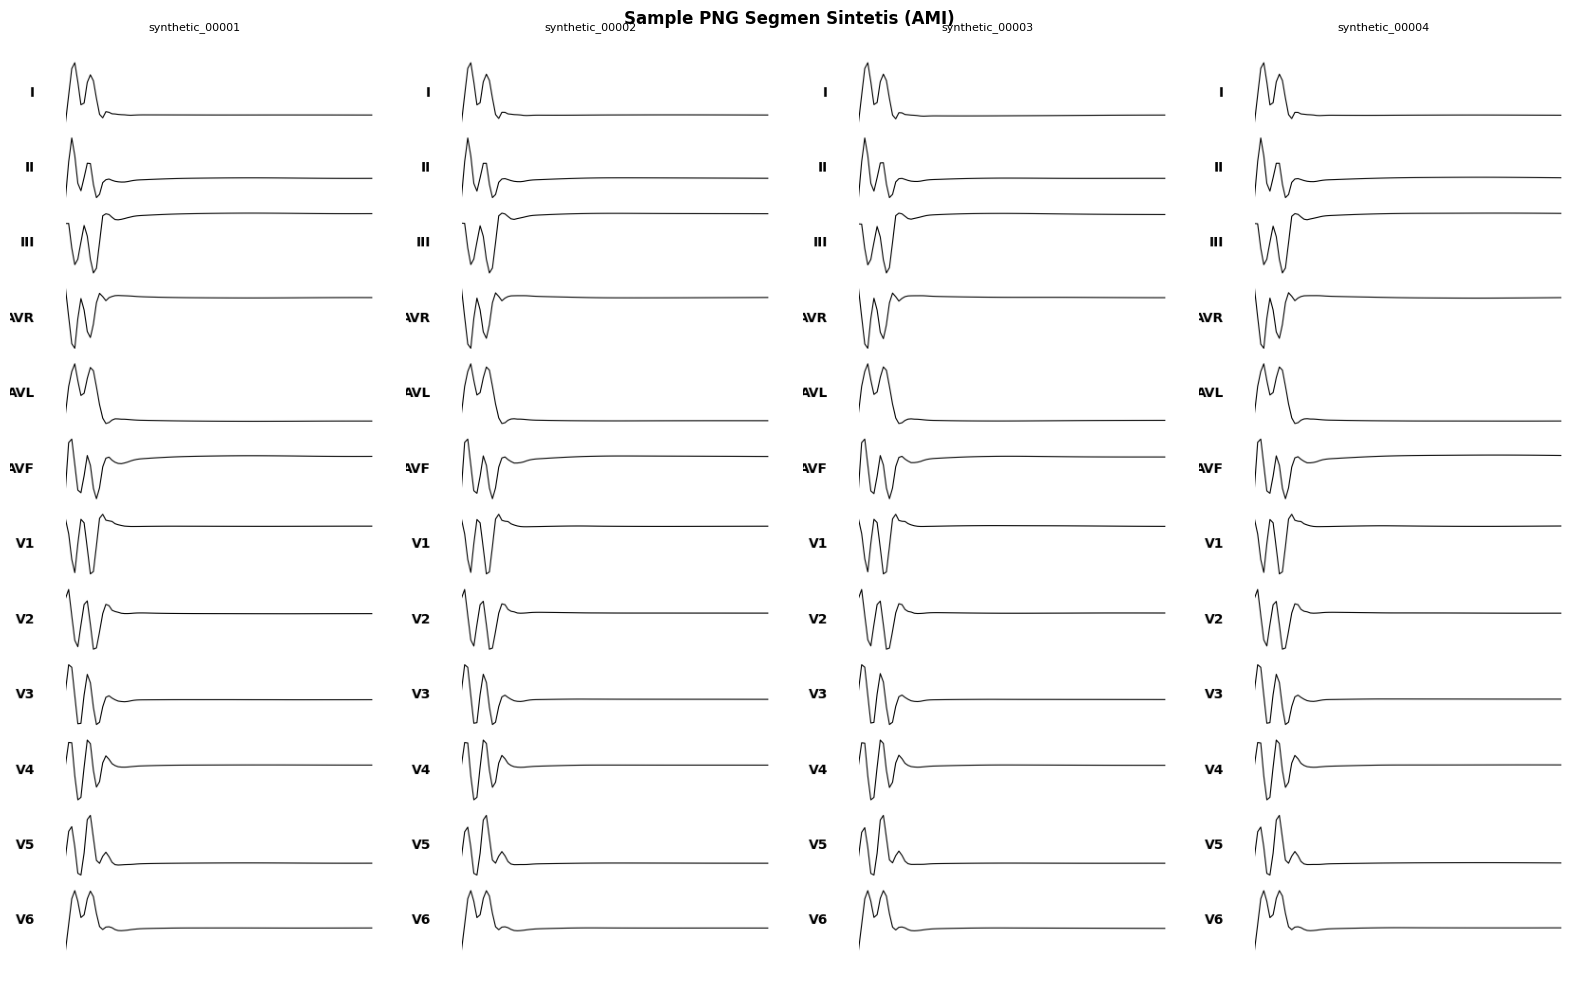

  📐 Ukuran: 390×989 px


In [21]:
# === Preview beberapa segmen sintetis ===
sample_pngs = sorted(glob.glob(f"{out_dir}/**/syn_*_seg00.png", recursive=True))[:4]

if sample_pngs:
    fig, axes = plt.subplots(1, len(sample_pngs), figsize=(4 * len(sample_pngs), 10))
    if len(sample_pngs) == 1:
        axes = [axes]
    for i, p in enumerate(sample_pngs):
        img = Image.open(p)
        axes[i].imshow(img)
        axes[i].set_title(os.path.basename(os.path.dirname(p)), fontsize=8)
        axes[i].axis('off')
    plt.suptitle('Sample PNG Segmen Sintetis (AMI)', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f"  📐 Ukuran: {img.size[0]}×{img.size[1]} px")
else:
    print("  ⚠ Tidak ada PNG untuk preview")

## 7. Summary & Cara Pakai

In [22]:
# === SUMMARY ===
total_png = sum(1 for _ in Path(out_dir).rglob("*.png"))

print("=" * 65)
print("🎉 ecgGAN PIPELINE SELESAI!")
print("=" * 65)
print(f"")
print(f"  📊 Ringkasan:")
print(f"     Data training    : {data_raw.shape[0]} sinyal AMI dari PTB-XL")
print(f"     Sampling rate    : {SAMPLING_RATE} Hz")
print(f"     Sinyal sintetis  : {N_GENERATE} × 10 detik")
print(f"     Segmen per EKG   : {N_SEGMENTS}")
print(f"     Total PNG segmen : {total_png}")
print(f"     Ukuran PNG       : {SEG_WIDTH}×{SEG_HEIGHT} px")
print(f"")
print(f"  📁 Output: {OUTPUT_DIR}/")
print(f"     └── synthetic_png/{CLASS_NAME}/")
print(f"         ├── synthetic_00001/ (10 segmen)")
print(f"         ├── synthetic_00002/ (10 segmen)")
print(f"         └── ... ({N_GENERATE} folder)")
print(f"")
print(f"  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  📋 CARA PAKAI DI ViT_2.ipynb:")
print(f"  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"")
print(f"  ⚠️  JANGAN copy ke folder data asli!")
print(f"     Data sintetis → TRAINING saja")
print(f"     Data asli     → TESTING saja")
print(f"")
print(f"  Di Cell 8 (data collection), tambahkan:")
print(f"")
print(f'  synth_dir = "{out_dir}"')
print(f"  for ecg_folder in os.listdir(synth_dir):")
print(f"      ep = os.path.join(synth_dir, ecg_folder)")
print(f"      if os.path.isdir(ep):")
print(f"          for f in os.listdir(ep):")
print(f"              if f.endswith('.png'):")
print(f"                  data.append({{")
print(f"                      'image_path': os.path.join(ep, f),")
print(f"                      'label': '{CLASS_NAME}',")
print(f"                      'label_idx': CLASS_TO_IDX['{CLASS_NAME}'],")
print(f"                      'ecg_id': ecg_folder,")
print(f"                      'source': 'synthetic'")
print(f"                  }})")
print(f"")
print(f"  # Di Cell 9 (split), tambahkan:")
print(f"  df.loc[df['source'] == 'synthetic', 'split'] = 'train'")
print(f"")
print("=" * 65)

🎉 ecgGAN PIPELINE SELESAI!

  📊 Ringkasan:
     Data training    : 353 sinyal AMI dari PTB-XL
     Sampling rate    : 100 Hz
     Sinyal sintetis  : 100 × 10 detik
     Segmen per EKG   : 10
     Total PNG segmen : 1001
     Ukuran PNG       : 390×989 px

  📁 Output: /workspace/ecg_gan_ami2/
     └── synthetic_png/AMI/
         ├── synthetic_00001/ (10 segmen)
         ├── synthetic_00002/ (10 segmen)
         └── ... (100 folder)

  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📋 CARA PAKAI DI ViT_2.ipynb:
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ⚠️  JANGAN copy ke folder data asli!
     Data sintetis → TRAINING saja
     Data asli     → TESTING saja

  Di Cell 8 (data collection), tambahkan:

  synth_dir = "/workspace/ecg_gan_ami2/synthetic_png/AMI"
  for ecg_folder in os.listdir(synth_dir):
      ep = os.path.join(synth_dir, ecg_folder)
      if os.path.isdir(ep):
          for f in os.listdir(ep):
              if f.endswith('.png'):
                  data.append({
      

Asli:     1790 PNG
Sintetis: 1000 PNG


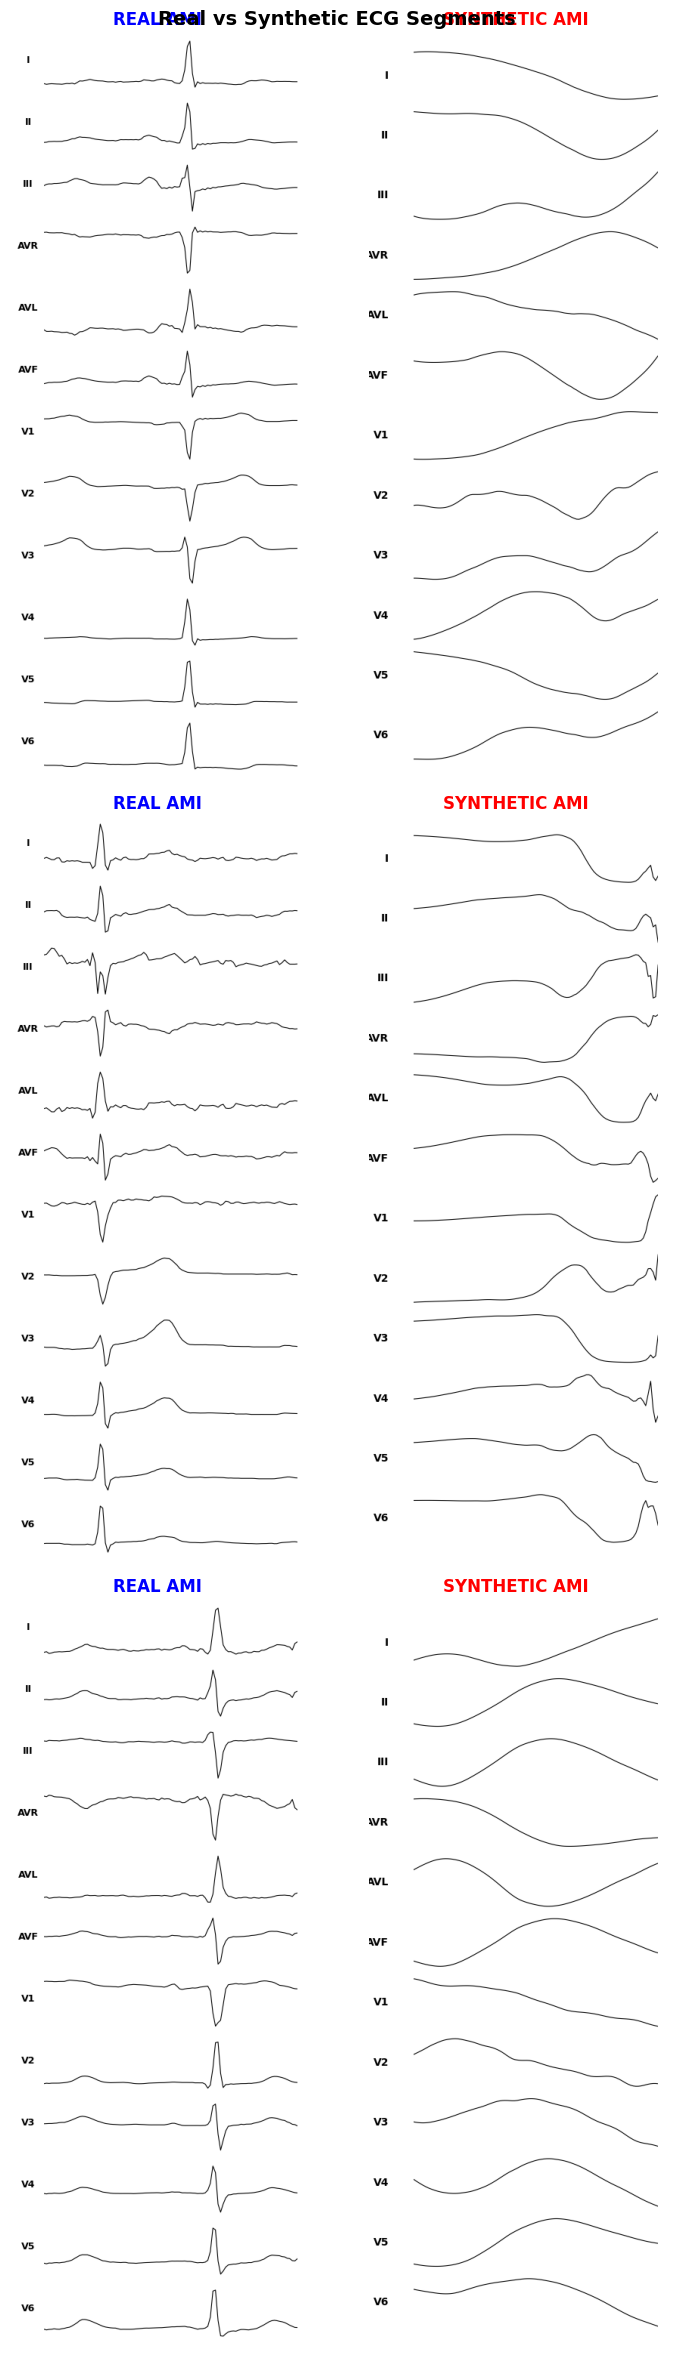

In [23]:
from PIL import Image
import matplotlib.pyplot as plt
import os, glob, random

# Path yang benar
synth_dir = "/workspace/ecg_gan_ami2/synthetic_png/AMI"
real_dir = "/workspace/data/png_segments/AMI"

synth_pngs = sorted(glob.glob(f"{synth_dir}/**/*.png", recursive=True))
real_pngs = sorted(glob.glob(f"{real_dir}/**/*.png", recursive=True))

print(f"Asli:     {len(real_pngs)} PNG")
print(f"Sintetis: {len(synth_pngs)} PNG")

# Tampilkan 3 asli vs 3 sintetis
fig, axes = plt.subplots(3, 2, figsize=(8, 24))

for i in range(3):
    rimg = Image.open(random.choice(real_pngs))
    axes[i][0].imshow(rimg)
    axes[i][0].set_title('REAL AMI', color='blue', fontweight='bold')
    axes[i][0].axis('off')

    simg = Image.open(random.choice(synth_pngs))
    axes[i][1].imshow(simg)
    axes[i][1].set_title('SYNTHETIC AMI', color='red', fontweight='bold')
    axes[i][1].axis('off')

plt.suptitle('Real vs Synthetic ECG Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
import os

real_base = "/workspace/data/png_segments/AMI"

if os.path.exists(real_base):
    items = os.listdir(real_base)[:5]
    print(f"Isi AMI folder ({len(os.listdir(real_base))} items):")
    for item in items:
        full = os.path.join(real_base, item)
        if os.path.isdir(full):
            files = os.listdir(full)[:3]
            print(f"  📁 {item}/ → {files}")
        else:
            print(f"  📄 {item}")
else:
    print(f"❌ Folder tidak ada: {real_base}")
    print(f"\nCek png_segments/:")
    base = "/workspace/data/ptb-xl/png_segments"
    if os.path.exists(base):
        for c in os.listdir(base):
            full = os.path.join(base, c)
            count = sum(1 for _ in glob.glob(f"{full}/**/*.png", recursive=True))
            print(f"  📁 {c}/ → {count} PNG")
    else:
        print(f"❌ {base} juga tidak ada")

Isi AMI folder (179 items):
  📁 00077_lr/ → ['00077_lr_seg00.png', '00077_lr_seg01.png', '00077_lr_seg02.png']
  📁 00418_lr/ → ['00418_lr_seg00.png', '00418_lr_seg01.png', '00418_lr_seg02.png']
  📁 00486_lr/ → ['00486_lr_seg00.png', '00486_lr_seg01.png', '00486_lr_seg02.png']
  📁 00507_lr/ → ['00507_lr_seg00.png', '00507_lr_seg01.png', '00507_lr_seg02.png']
  📁 00600_lr/ → ['00600_lr_seg00.png', '00600_lr_seg01.png', '00600_lr_seg02.png']
